# Decision Trees model for kiki project (Extra-Trees)

**Author:** Aniket Angre<br>
**Date created:** 2023/06/31<br>
**Last modified:** 2025/01/01<br>
**Description:** Multivariate regression for structured data including numerical and categorical features. This script implements decision tree models to learn the features.<br>
Three different models are created using decision trees in scikit-learn library. The first one implements single decision tree regressor and other two use ensemble techniques, mainly RandomForestRegressor and ExtraTreesRegressor.<br>

This notebook makes use of tensorflow and could also access dedicated GPU if it is present in the computer.

In [1]:
# Load important libraries
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn as sk
import logging
import os
from tensorflow.python.client import device_lib
tf.get_logger().setLevel(logging.ERROR)

def get_available_gpus():
    local_device_protos = device_lib.list_local_devices()
    return [x.name for x in local_device_protos if x.device_type == 'GPU']

print("Tensorflow version : ", tf.version.VERSION)
print("Cuda available : ", tf.test.is_built_with_cuda())
print("Available GPU : ", get_available_gpus())

Tensorflow version :  2.10.1
Cuda available :  True
Available GPU :  ['/device:GPU:0']


### Parameter description
**main_dir** : Main directory where all model folders are kept<br>
**foldername** : name of the folder where the current script is placed<br>
**all_params** : to set either all_parameters or specific parameters in the dataset<br>
**databse_filepath** : filepath of the dataset you want to load (mostly pre-processed database)<br>
**reordered_columns** : columns that should be used in the training process<br>
**input_columns** : inputs for the NN model<br>
**output_columns** : outputs for the NN model<br>

The dataset consists of following dependent and independent variables <br>
**body_wt** : body weight of the person<br>
**mat_11, mat_12, mat_13, mat_22, mat_23, mat_33, mat_44, mat_55, mat_66** : desired material properties of the lattice structure<br>
**max_disp** : maximum allowed displacement<br>
**max_stress** : maximum allowed stress<br>
**area_to_vol** : ratio of area of the lattice structure to its volume<br>
**support_vol** : volume of the support material required in case of 3D printing<br>
**vol_frac** : volume fraction of the lattice structure<br>

In [2]:
# Extract filename  .. please change as per computer
main_dir = os.path.dirname(os.getcwd())
foldername = os.path.split(os.getcwd())[-1]
all_params = False

# Import dataset 
database_filepath = os.path.join(main_dir, "database_upd.xlsx")
df = pd.read_excel(database_filepath, engine='openpyxl')

# Drop index column and all rows with NaN values
df.dropna(axis=0, inplace=True)
df.reset_index(drop=True)

# Create new columns from the catergorical variables
df2 = pd.get_dummies(df['cell_type']).astype(dtype=int)
df = pd.concat([df, df2], axis=1)
df.drop(columns=['sr_no', 'cell_type'], inplace=True)

# Reorient the pandas dataframe
if not all_params:
    reordered_columns = ['body_wt (kg)', 'mat_11 (MPa)', 'mat_12 (MPa)', 'mat_13 (MPa)', 'mat_22 (MPa)', 'mat_23 (MPa)', 'mat_33 (MPa)', 'mat_44 (MPa)', 'mat_55 (MPa)',
                       'mat_66 (MPa)', 'max_disp (mm)', 'max_stress (MPa)', 'vol_frac', 'vox_to_surf (mm)', 'x_rot (deg)', 'y_rot (deg)', 'z_rot (deg)',  'BCC', 'DTPMS', 'FCC',
                       'FLU', 'GYR', 'KEV', 'OCT', 'SC', 'SCH', 'SPP', 'DIA', 'HCG', 'TEG3', 'PSM2', 'RDO', 'DDK2']
    input_columns = reordered_columns[:14]
    output_columns = reordered_columns[14:]
else:
    reordered_columns = ['body_wt (kg)', 'mat_11 (MPa)', 'mat_12 (MPa)', 'mat_13 (MPa)', 'mat_22 (MPa)', 'mat_23 (MPa)', 'mat_33 (MPa)', 'mat_44 (MPa)', 'mat_55 (MPa)',
                       'mat_66 (MPa)', 'max_disp (mm)', 'max_stress (MPa)', 'vol_frac', 'area_to_vol (mm^-1)', 'support_vol (mm^3)', 'vox_to_surf (mm)', 'x_rot (deg)', 'y_rot (deg)', 'z_rot (deg)', 
                       'BCC', 'DTPMS', 'FCC', 'FLU', 'GYR', 'KEV', 'OCT', 'SC', 'SCH', 'SPP', 'DIA', 'HCG', 'TEG3', 'PSM2', 'RDO', 'DDK2']
    input_columns = reordered_columns[:16]
    output_columns = reordered_columns[16:]

df = df.loc[:, reordered_columns]

### Normalize the pre-processed dataset and get dataset partitions
**def normalize** : takes dataset in pandas format and returns the normalized dataset with normalization parameters<br>
**def get_dataset_partition** : partition the dataset into training, validation and testing dataset<br>
**x_train, y_train** : training dataset in numpy format<br>
**x_test, y_test** : testing dataset in numpy format<br>

In [3]:
# Create normalisation function
def normalize(df, excluded_columns = None):
    # Shuffle pandas datframe 
    df = df.sample(frac=1, random_state=1).reset_index(drop=True)
    
    # Find dataframe excluding specified columns
    if excluded_columns is not None:
        df_excluded = df[excluded_columns]
        df_numeric = df[df.columns.difference(excluded_columns)]
    else:
        df_numeric = df
    
    # Normalize dataframe using Min/Max Normalization.
    normalized_df = (df_numeric - df_numeric.min())/(df_numeric.max() - df_numeric.min())
    if excluded_columns is not None:
        for i in range(len(excluded_columns)):
            normalized_df[excluded_columns[i]] = df[excluded_columns[i]]
    
    # Min and max values of columns (Normalizer)
    normalizer = np.vstack((df_numeric.max(), df_numeric.min())).transpose()
    normalizer_df = pd.DataFrame(normalizer, columns = ['max', 'min'])
    normalizer_df.index = df_numeric.columns
    
    return normalized_df, normalizer_df

# Create dataset partition function
def get_dataset_partitions(df, train_split=0.8, val_split=0.1, test_split=0.1):
    assert (train_split + test_split + val_split) == 1
     
    if not isinstance(df, pd.DataFrame):
        raise Exception("Only pandas dataframes are allowed !")
    
    # Split the data into three different sets
    indices_or_sections = np.array([int(train_split * df.shape[0]), int((train_split + val_split) * df.shape[0])])
    train_df = df.loc[:indices_or_sections[0]-1]
    val_df = df.loc[indices_or_sections[0]:indices_or_sections[1]-1]
    test_df = df.loc[indices_or_sections[1]:]
    
    # return
    return train_df, val_df, test_df

# Save normalization parameters of the data
normalized_df, normalizer_df = normalize(df)

# Get sizes of the available train, validation and test datasets
train_df, val_df, test_df = get_dataset_partitions(normalized_df, train_split = 0.9, val_split = 0.0, test_split = 0.1)
print("Size of training dataset : ", train_df.shape)
print("Size of validation dataset : ", val_df.shape)
print("Size of testing dataset : ", test_df.shape)

# Save necessary files
base_filename = foldername.split('.')[0]
if all_params:
    base_filename = base_filename + '_all_params'
normalizer_df.to_csv(base_filename + '_normalizer.csv')
train_df.to_csv(base_filename + '_norm_train.csv')
test_df.to_csv(base_filename + '_norm_test.csv')

# Get the sizes of model inputs and outputs
x_train, y_train = train_df[input_columns].to_numpy(), train_df[output_columns].to_numpy()
x_test, y_test = test_df[input_columns].to_numpy(), test_df[output_columns].to_numpy()
x_normalizer, y_normalizer = normalizer_df.loc[input_columns].to_numpy(), normalizer_df.loc[output_columns].to_numpy()
print("Number of input parameters : ", x_train.shape[1])
print("Number of output parameters : ", y_train.shape[1])

model_name = 'model_22v'
if all_params:
    model_name = model_name + '_all_params'

Size of training dataset :  (36855, 33)
Size of validation dataset :  (0, 33)
Size of testing dataset :  (4095, 33)
Number of input parameters :  14
Number of output parameters :  19


### Create model using single Decision Tree
This model uses single decision tree to learn the data<br>
**max_depth** : maximum depth of the decision tree<br>
__[Click the link for more information about Decision Tree Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor)__

In [4]:
from sklearn.tree import DecisionTreeRegressor
# Fit the data with Decision tree regressor 
regr_1 = DecisionTreeRegressor(max_depth=500, random_state=10)
regr_1.fit(x_train, y_train)
rscore_1 = regr_1.score(x_test, y_test)
print("Score:", rscore_1)

Score: 0.8917887059177556


### Create model using Random Forests
This model uses forest of slightly randomized trees to learn the data.<br>
A random forest is a meta estimator that fits a number of classifying decision trees on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.<br>
**max_depth** : maximum depth of the decision tree<br>
**n_estimators** : number of estimators (estimator=DecisionTreeRegressor) that the model uses to learn the data<br>
__[Click the link for more information about Random Forest Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor)__

In [5]:
from sklearn.ensemble import RandomForestRegressor
# Fit the data with Random Forest regressor 
regr_2 = RandomForestRegressor(max_depth=50, n_estimators=100, random_state=10) #max_depth=300
regr_2.fit(x_train, y_train)
rscore_2 = regr_2.score(x_test, y_test)
print("Score:", rscore_2)

Score: 0.9563544552018394


### Create model using Forest of Randomized Trees
This model uses set of extremely random trees to learn the data.<br> 
This class implements a meta estimator that fits a number of randomized decision trees (a.k.a. extra-trees) on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.<br>
__[Click the link for more information about Extremely Randomized Trees](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesRegressor.html#sklearn.ensemble.ExtraTreesRegressor)__

**Extra Trees** is an ensemble method that builds multiple decision trees with added randomness to improve generalization and reduce overfitting.

🔑 Key Concepts

- **Ensemble of Trees**: Combines predictions from many decision trees for better accuracy.
- **Random Splits**: Selects both features **and split thresholds randomly**, unlike Random Forests which find the best split.
- **No Bootstrapping**: Uses the **entire training set** instead of bootstrapped samples.

🎯 Why Randomization Helps

- **Reduces Overfitting**: Random thresholds prevent trees from fitting noise.
- **Improves Generalization**: More diverse trees reduce variance in predictions.
- **Acts as Regularization**: Limits model complexity without manual penalties.

In [6]:
from sklearn.ensemble import ExtraTreesRegressor
# Fit the data with Extremely Random Forest regressor 
regr_3 = ExtraTreesRegressor(max_depth=50, n_estimators=100, random_state=10) #max_depth=300
regr_3.fit(x_train, y_train)
rscore_3 = regr_3.score(x_test, y_test)
print("Score:", rscore_3)

Score: 0.9960541073566167


### Evaluate the Extremely Randomized Trees

Evaluate the trained neural networks model with testing dataset<br>
**y_pred** : output predicted by trained model<br>
**y_true** : expected output<br>

In [7]:
from sklearn.metrics import mean_absolute_error, accuracy_score

# Evaluate model 
def evaluateModel(model, x_test, y_test, normalizer = (x_normalizer, y_normalizer)):

    def denormalize(y, y_normalizer):
        return y * (y_normalizer[:, 0] - y_normalizer[:, 1]) + y_normalizer[:, 1]

    if x_test.ndim == 1:
        print("Predicting output for one input set.")
        # If only one input for testing is given
        y_true = denormalize(y_test, y_normalizer)
        y_pred_bn = model.predict(np.expand_dims(x_test, axis = 0))[0]
        y_pred = denormalize(y_pred_bn, y_normalizer)
        
        # Calculate the accuracies
        y_pred_regr_mae = mean_absolute_error(y_true[:3], y_pred[:3])
        y_pred_class_acc = accuracy_score([np.argmax(y_true[3:])], [np.argmax(y_pred[3:])]) * 100

    elif x_test.ndim == 2:
        print("Predicting output for multiple sets of inputs.")
        # If there are more than one inputs to be checked
        y_true = denormalize(y_test, y_normalizer)
        y_pred_bn = model.predict(x_test)
        y_pred = denormalize(y_pred_bn, y_normalizer)   
         
        # Calculate the accuracies
        y_pred_regr_mae = mean_absolute_error(y_true[:,:3], y_pred[:,:3])
        y_pred_class_acc = accuracy_score(np.argmax(y_true[:,3:], axis=1), np.argmax(y_pred[:,3:], axis=1)) * 100

    else:
        print("Please pass appropriate set of inputs to predict output.")
        return None, None

    return y_pred_regr_mae, y_pred_class_acc

In [ ]:
# Evaluate the model 
#y_pred = evaluateModel(model, x_test[0], y_test[0])
y_pred_regr_mae, y_pred_class_acc = evaluateModel(regr_3, x_test, y_test)
print("Orientation prediction within : +/-", y_pred_regr_mae, "°")
print("Cell type prediction accuracy :", y_pred_class_acc, "%")

Predicting output for multiple sets of inputs.
Orientation prediction within : +/- 0.7482714111285628 °
Cell type prediction accuracy : 100.0 %


### Save model

Save the model to a dedicated 'saved_model' folder using pickle<br>
**model_save_path** : Path where the model should be saved<br>

In [12]:
import pickle
# Save the model weights 
model_save_filepath = os.path.join(main_dir, foldername, "trained_models", model_name + ".joblib")

# save model
model = regr_3
pickle.dump(model, open(model_save_filepath, "wb"))

# load model
loaded_model = pickle.load(open(model_save_filepath, "rb"))

### Plot results

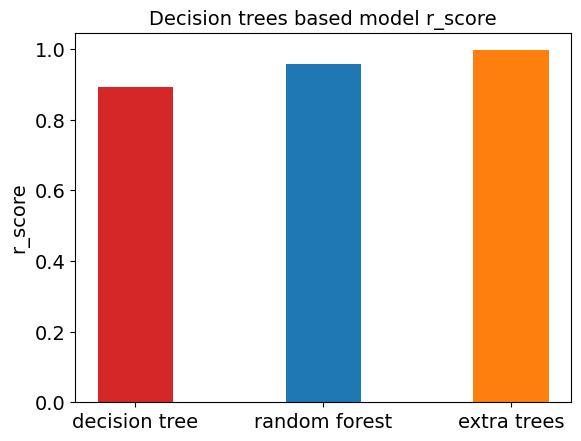

In [13]:
# Plot results
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', size=14)
matplotlib.rc('axes', titlesize=14)
fig, ax = plt.subplots()
model_names = ['decision tree', 'random forest', 'extra trees']
r_scores = [rscore_1, rscore_2, rscore_3]
bar_labels = ['red', 'blue', 'orange']
bar_colors = ['tab:red', 'tab:blue', 'tab:orange']
ax.bar(model_names, r_scores, label=bar_labels, color=bar_colors, width = 0.40)
ax.set_ylabel('r_score')
ax.set_title('Decision trees based model r_score')
#ax.legend(title='models')
plt.show()